# SpaceX Missions Analysis
In this notebook, I worked on SpaceX mission data and trained RNN, LSTM, and GRU models for practice.

## 1. Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## 2. Load Data

In [2]:
df = pd.read_csv('data/raw/database.csv')
print(df.shape)
df.head()

(41, 16)


,Flight Number,Launch Date,Launch Time,Launch Site,Vehicle Type,Payload Name,Payload Type,Payload Mass (kg),Payload Orbit,Customer Name,Customer Type,Customer Country,Mission Outcome,Failure Reason,Landing Type,Landing Outcome
0,F1-1,24 March 2006,22:30,Marshall Islands,Falcon 1,FalconSAT-2,Research Satellite,19.5,NaN,DARPA,Government,United States,Failure,Engine Fire During Launch,NaN,NaN
1,F1-2,21 March 2007,01:10,Marshall Islands,Falcon 1,DemoSat,NaN,NaN,NaN,DARPA,Government,United States,Failure,Engine Shutdown During Launch,NaN,NaN
2,F1-3,3 August 2008,03:34,Marshall Islands,Falcon 1,Trailblazer,Communication Satellite,NaN,NaN,ORS,Government,United States,Failure,Collision During Launch,NaN,NaN
3,F1-3,3 August 2008,03:34,Marshall Islands,Falcon 1,"PRESat, NanoSail-D",Research Satellites,8.0,NaN,NASA,Government,United States,Failure,Collision During Launch,NaN,NaN
4,F1-3,3 August 2008,03:34,Marshall Islands,Falcon 1,Explorers,Human Remains,NaN,NaN,Celestis,Business,United States,Failure,Collision During Launch,NaN,NaN


## 3. Descriptive Statistics

In [3]:
df.describe(include='all')

,Flight Number,Launch Date,Launch Time,Launch Site,Vehicle Type,Payload Name,Payload Type,Payload Mass (kg),Payload Orbit,Customer Name,Customer Type,Customer Country,Mission Outcome,Failure Reason,Landing Type,Landing Outcome
count,41,41,41,41,41,41,38,33.000000,36,39,39,39,41,8,21,21
unique,36,36,35,4,4,41,7,NaN,4,18,2,11,2,6,4,2
top,F1-3,3 August 2008,03:34,Cape Canaveral AFS LC-40,Falcon 9 (v1.1),FalconSAT-2,Communication Satellite,NaN,Low Earth Orbit,NASA,Government,United States,Success,Collision During Launch,Ship,Success
freq,3,3,3,30,16,1,19,NaN,19,13,20,23,33,3,11,12
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2739.772727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2131.502973,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,570.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2490.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4159.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.isnull().sum()

Flight Number         0
Launch Date           0
Launch Time           0
Launch Site           0
Vehicle Type          0
Payload Name          0
Payload Type          3
Payload Mass (kg)     8
Payload Orbit         5
Customer Name         2
Customer Type         2
Customer Country      2
Mission Outcome       0
Failure Reason       33
Landing Type         20
Landing Outcome      20
dtype: int64

## 4. EDA with Seaborn Plots

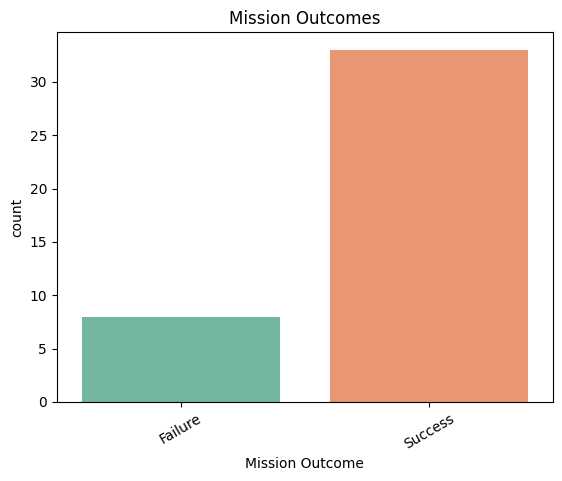

In [5]:
# Mission Outcome count
sns.countplot(data=df, x='Mission Outcome', palette='Set2')
plt.title('Mission Outcomes')
plt.xticks(rotation=30)
plt.show()

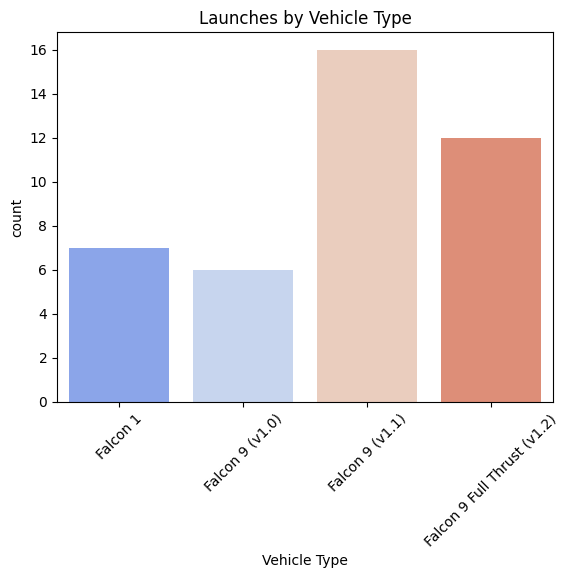

In [6]:
# Launches by Vehicle Type
sns.countplot(data=df, x='Vehicle Type', palette='coolwarm')
plt.title('Launches by Vehicle Type')
plt.xticks(rotation=45)
plt.show()

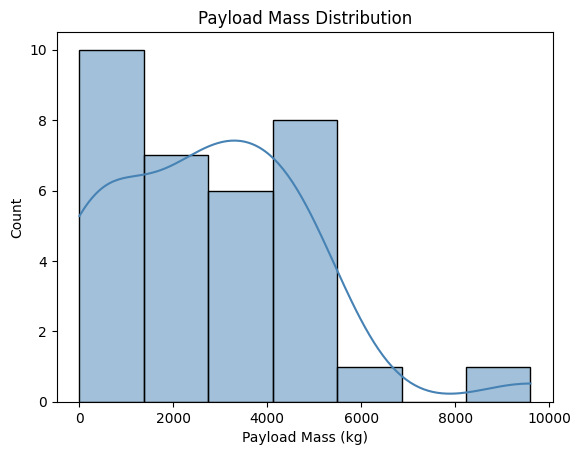

In [7]:
# Payload Mass distribution
sns.histplot(df['Payload Mass (kg)'].dropna(), kde=True, color='steelblue')
plt.title('Payload Mass Distribution')
plt.show()

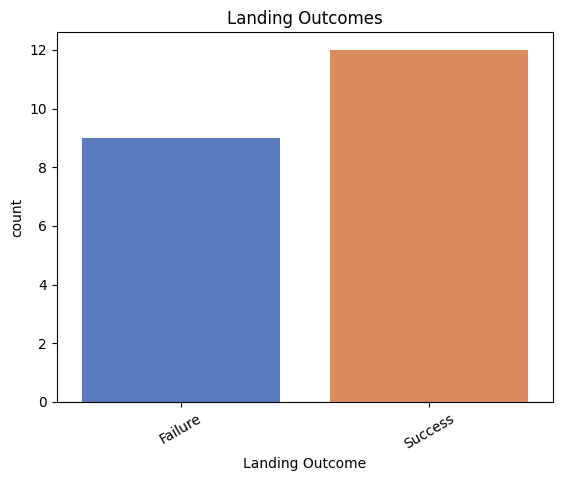

In [8]:
# Landing Outcome
sns.countplot(data=df, x='Landing Outcome', palette='muted')
plt.title('Landing Outcomes')
plt.xticks(rotation=30)
plt.show()

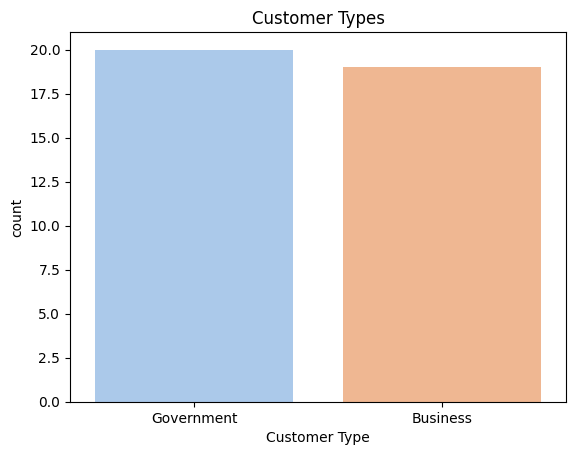

In [9]:
# Customer Type
sns.countplot(data=df, x='Customer Type', palette='pastel')
plt.title('Customer Types')
plt.show()

## 5. Preprocessing

In [10]:
# Parse year from Launch Date
df['Year'] = pd.to_datetime(df['Launch Date'], dayfirst=True, errors='coerce').dt.year

# Fill missing Payload Mass with median
df['Payload Mass (kg)'] = df['Payload Mass (kg)'].fillna(df['Payload Mass (kg)'].median())

# Encode categorical columns
le = LabelEncoder()
for col in ['Vehicle Type', 'Mission Outcome', 'Landing Outcome', 'Customer Type']:
    df[col] = df[col].fillna('Unknown')
    df[col] = le.fit_transform(df[col])

df = df.dropna(subset=['Year'])
df = df.sort_values('Year').reset_index(drop=True)

print("Shape after preprocessing:", df.shape)
df[['Year','Vehicle Type','Payload Mass (kg)','Mission Outcome','Landing Outcome']].head()

Shape after preprocessing: (41, 17)


,Year,Vehicle Type,Payload Mass (kg),Mission Outcome,Landing Outcome
0,2006,0,19.5,0,2
1,2007,0,2490.0,0,2
2,2008,0,2490.0,0,2
3,2008,0,8.0,0,2
4,2008,0,2490.0,0,2


## 6. Prepare Time Series Sequences

In [11]:
features = ['Vehicle Type', 'Payload Mass (kg)', 'Customer Type', 'Landing Outcome']
target   = 'Mission Outcome'

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df[features + [target]])

X_all = data_scaled[:, :-1]
y_all = data_scaled[:, -1]

# Create sequences
def make_sequences(X, y, steps=3):
    Xs, ys = [], []
    for i in range(len(X) - steps):
        Xs.append(X[i:i+steps])
        ys.append(y[i+steps])
    return np.array(Xs), np.array(ys)

SEQ = 3
X_seq, y_seq = make_sequences(X_all, y_all, SEQ)

split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (30, 3, 4) | Test: (8, 3, 4)


## 7. RNN Model

In [12]:
rnn = Sequential([
    SimpleRNN(32, activation='tanh', input_shape=(SEQ, X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])
rnn.compile(optimizer='adam', loss='mse')
rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (4.75 KB)

 Trainable params: 1,217 (4.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
es = EarlyStopping(patience=10, restore_best_weights=True)
rnn_hist = rnn.fit(X_train, y_train, epochs=100, batch_size=4,
                   validation_data=(X_test, y_test),
                   callbacks=[es], verbose=0)

rnn_pred = rnn.predict(X_test)
print("RNN  | MAE:", round(mean_absolute_error(y_test, rnn_pred), 4),
      "| R²:", round(r2_score(y_test, rnn_pred), 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
RNN  | MAE: 0.2202 | R²: 0.0352


## 8. LSTM Model

In [ ]:
lstm = Sequential([
    LSTM(32, activation='tanh', input_shape=(SEQ, X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')

lstm_hist = lstm.fit(X_train, y_train, epochs=100, batch_size=4,
                     validation_data=(X_test, y_test),
                     callbacks=[EarlyStopping(patience=10, restore_best_weights=True)], verbose=0)

lstm_pred = lstm.predict(X_test)
print("LSTM | MAE:", round(mean_absolute_error(y_test, lstm_pred), 4),
      "| R²:", round(r2_score(y_test, lstm_pred), 4))

## 9. GRU Model

In [ ]:
gru = Sequential([
    GRU(32, activation='tanh', input_shape=(SEQ, X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])
gru.compile(optimizer='adam', loss='mse')

gru_hist = gru.fit(X_train, y_train, epochs=100, batch_size=4,
                   validation_data=(X_test, y_test),
                   callbacks=[EarlyStopping(patience=10, restore_best_weights=True)], verbose=0)

gru_pred = gru.predict(X_test)
print("GRU  | MAE:", round(mean_absolute_error(y_test, gru_pred), 4),
      "| R²:", round(r2_score(y_test, gru_pred), 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
GRU  | MAE: 0.2325 | R²: -0.12


## 10. Loss Curves

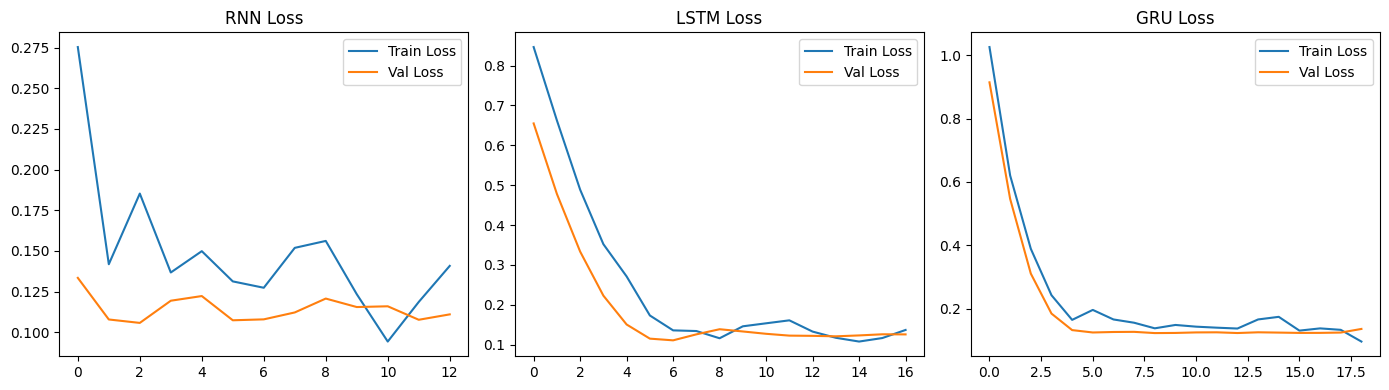

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, hist, name in zip(axes,
                           [rnn_hist, lstm_hist, gru_hist],
                           ['RNN', 'LSTM', 'GRU']):
    ax.plot(hist.history['loss'],     label='Train Loss')
    ax.plot(hist.history['val_loss'], label='Val Loss')
    ax.set_title(f'{name} Loss')
    ax.legend()

plt.tight_layout()
plt.show()

## 11. Actual vs Predicted for All Models

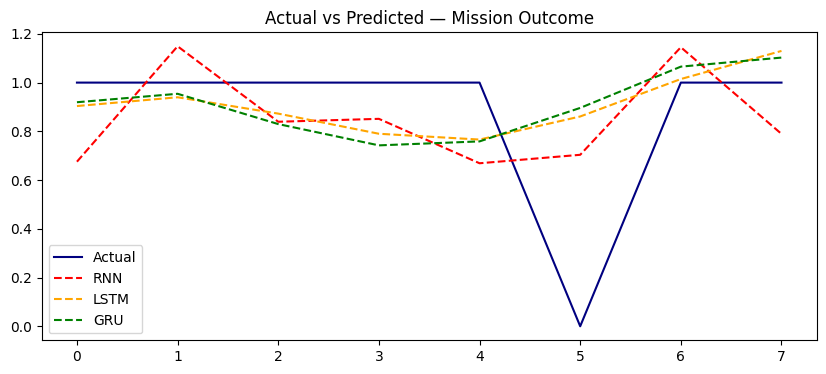

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(y_test, label='Actual', color='navy')
plt.plot(rnn_pred,  label='RNN',  linestyle='--', color='red')
plt.plot(lstm_pred, label='LSTM', linestyle='--', color='orange')
plt.plot(gru_pred,  label='GRU',  linestyle='--', color='green')
plt.title('Actual vs Predicted — Mission Outcome')
plt.legend()
plt.show()

## 12. Model Comparison

         MAE      R2
RNN   0.2717  0.0335
LSTM  0.2166 -0.0128
GRU   0.2325 -0.1200


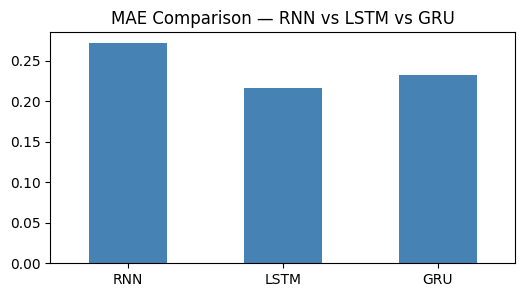

In [ ]:
results = {
    'RNN' : {'MAE': mean_absolute_error(y_test, rnn_pred),  'R2': r2_score(y_test, rnn_pred)},
    'LSTM': {'MAE': mean_absolute_error(y_test, lstm_pred), 'R2': r2_score(y_test, lstm_pred)},
    'GRU' : {'MAE': mean_absolute_error(y_test, gru_pred),  'R2': r2_score(y_test, gru_pred)},
}

summary = pd.DataFrame(results).T.round(4)
print(summary)

summary['MAE'].plot(kind='bar', color='steelblue', figsize=(6,3))
plt.title('MAE Comparison — RNN vs LSTM vs GRU')
plt.xticks(rotation=0)
plt.show()

## 13. Save Models

In [ ]:
rnn.save('rnn_spacex.h5')
lstm.save('lstm_spacex.h5')
gru.save('gru_spacex.h5')
print("Models saved.")

Models saved.
